Initial EDA

In [24]:
import pandas as pd
import duckdb 
import matplotlib.pyplot as plt

df = pd.read_csv('../data_files/alvsjo_data_raw.csv')

df

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,Marino,restaurant,Restaurang & Snabbmat,Klubbacken,51,59.305325,17.963290
1,Hemköp Stockholm Älvsjö,supermarket,Matbutik,Sjättenovembervägen,208,59.278752,18.002280
2,OKQ8,fuel,Bensinmack,NaN,NaN,59.294435,18.002588
3,Circle K,fuel,Bensinmack,NaN,NaN,59.299954,18.012147
4,McDonald's,fast_food,Restaurang & Snabbmat,NaN,NaN,59.293074,18.001211
...,...,...,...,...,...,...,...
540,Lekplats,playground,Lekplats,NaN,NaN,59.303276,18.016878
541,Lekplats,playground,Lekplats,NaN,NaN,59.299426,18.001098
542,Lekplats,playground,Lekplats,NaN,NaN,59.291422,17.980889
543,Lekplats,playground,Lekplats,NaN,NaN,59.282429,17.975122


In [25]:
df.columns

Index(['Namn', 'Typ', 'Kategori', 'Gata', 'Nr', 'Lat', 'Lon'], dtype='str')

In [26]:
df.describe()

,Lat,Lon
count,545.000000,545.000000
mean,59.296407,17.996263
std,0.011657,0.022851
min,59.264781,17.943174
25%,59.286200,17.976784
50%,59.298668,18.000730
75%,59.305760,18.012823
max,59.316601,18.037330


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Namn      545 non-null    str    
 1   Typ       545 non-null    str    
 2   Kategori  544 non-null    str    
 3   Gata      115 non-null    str    
 4   Nr        110 non-null    str    
 5   Lat       545 non-null    float64
 6   Lon       545 non-null    float64
dtypes: float64(2), str(5)
memory usage: 50.3 KB


Check for null values

In [28]:
duckdb.sql(
    """--sql
    SELECT * FROM df
    WHERE Namn IS NULL OR Typ IS NULL OR Kategori IS NULL OR Gata IS NULL OR Nr IS NULL or Lat IS NULL or Lon IS NULL
    """
).df().head()

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,OKQ8,fuel,Bensinmack,NaN,NaN,59.294435,18.002588
1,Circle K,fuel,Bensinmack,NaN,NaN,59.299954,18.012147
2,McDonald's,fast_food,Restaurang & Snabbmat,NaN,NaN,59.293074,18.001211
3,Sushi Bar,restaurant,Restaurang & Snabbmat,NaN,NaN,59.292424,17.967934
4,Lekplats,playground,Lekplats,NaN,NaN,59.264781,17.984072


Kolla efter dubletter

<Axes: xlabel='Namn'>

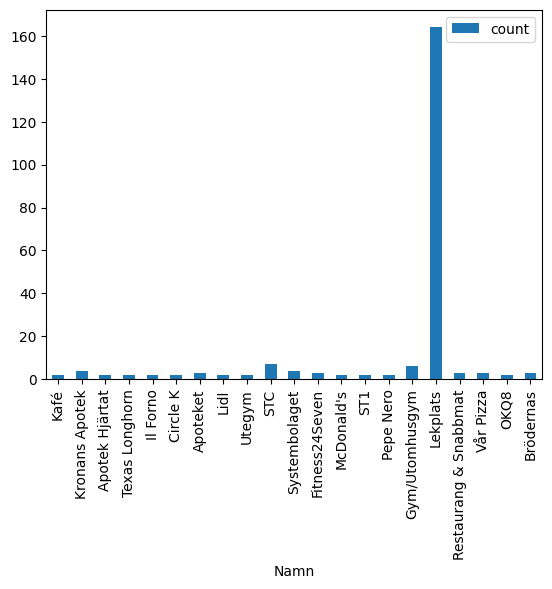

In [29]:
duckdb.sql(
    """--sql
        SELECT Namn, COUNT(*) as count
        FROM df
        WHERE NOT NAMN IS NULL
        GROUP BY Namn
        HAVING COUNT(*) > 1;
    """).df().plot(kind='bar', x='Namn', y='count') 

Dubletter som troligen är samma 

In [30]:
duckdb.sql(
    """---sql
    SELECT Namn, 
           ROUND(Lat, 3) as lat_r, 
           ROUND(Lon, 3) as lon_r, 
           COUNT(*) as count
    FROM df
    WHERE Namn IS NOT NULL
    GROUP BY Namn, ROUND(Lat, 3), ROUND(Lon, 3)
    HAVING COUNT(*) > 1
"""
).df()

,Namn,lat_r,lon_r,count
0,Lekplats,59.272,17.985,2
1,Lekplats,59.308,17.995,2
2,Lekplats,59.306,18.037,2
3,Lekplats,59.291,17.968,2
4,Lekplats,59.301,17.994,2
5,Lekplats,59.294,17.970,2
6,Lekplats,59.292,17.965,2
7,Lekplats,59.305,18.026,2
8,Lekplats,59.315,17.989,2
9,Lekplats,59.309,17.994,2


Kolla antal platser per kategori

<Axes: xlabel='Kategori'>

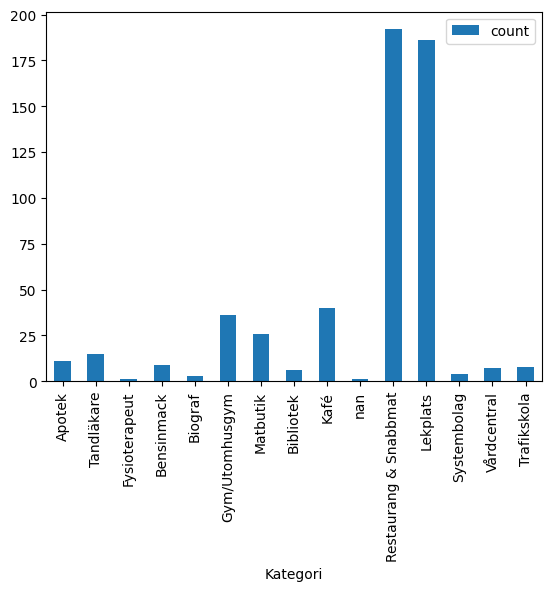

In [31]:
duckdb.sql(
    """--sql
    SELECT Kategori, COUNT(*) as count
    FROM df
    GROUP BY Kategori
    """).df().plot(kind='bar', x='Kategori', y='count')

Kolla var gatunamn inte finns

In [32]:
duckdb.sql(
    """--sql
    SELECT Gata, COUNT(*) as count
    FROM df
    WHERE Gata IS NULL
    GROUP BY Gata
    """).df()   

,Gata,count
0,None,430


EDA on skolor.csv

In [33]:
df2 = pd.read_csv('../data_files/skolor_raw.csv')

df2

,id,kategori,namn,gatuadress,postnummer,stad,koordinat_east,koordinat_north
0,13450,grundskolor,"Abrahamsbergsskolan, F–9",Gustav III:s väg 2–10,16830,Bromma,147176,6579984
1,15250,grundskolor,"Adolfsbergsskolan, F–6",Gårdsfogdevägen 18B,16866,Bromma,147359,6582509
2,13478,grundskolor,"Alviksskolan, F–9",Tranebergsvägen 79,16745,Bromma,148641,6580076
3,15106,grundskolor,"Apolloniosskolan, F–9",Stora Mans väg 11B,12559,Älvsjö,148591,6573949
4,13499,grundskolor,"Aspuddens skola, F–9",Blommensbergsvägen 166,12655,Hägersten,149899,6577119
...,...,...,...,...,...,...,...,...
249,9639,förskola,Älvsjö förskola,Långbrodalsvägen 1,12532,Älvsjö,150109,6573809
250,7834,förskola,Älvsjöbarnen,Murgrönsvägen 17,12555,Älvsjö,148168,6573488
251,6792,förskola,Älvskogen,Långsjövägen 33,12530,Älvsjö,149677,6573107
252,9546,förskola,Ängbygården – Ängbybarnens förskolor,Vultejusvägen 63–67,16866,Bromma,144794,6580868


In [34]:
df2.describe()

,id,postnummer,koordinat_east,koordinat_north
count,254.000000,254.000000,254.000000,2.540000e+02
mean,11250.031496,14644.566929,148053.185039,6.577782e+06
std,5076.316345,2070.094094,2155.130216,3.209559e+03
min,6361.000000,12530.000000,142790.000000,6.572317e+06
25%,8298.750000,12636.500000,146771.750000,6.574794e+06
50%,9630.000000,12951.000000,148347.000000,6.576974e+06
75%,14176.000000,16844.000000,149591.000000,6.580737e+06
max,34957.000000,16877.000000,152359.000000,6.583538e+06


In [35]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               254 non-null    int64
 1   kategori         254 non-null    str  
 2   namn             254 non-null    str  
 3   gatuadress       254 non-null    str  
 4   postnummer       254 non-null    int64
 5   stad             254 non-null    str  
 6   koordinat_east   254 non-null    int64
 7   koordinat_north  254 non-null    int64
dtypes: int64(4), str(4)
memory usage: 31.4 KB


Kolla tomma celler

In [36]:
df2.isnull().sum()

id                 0
kategori           0
namn               0
gatuadress         0
postnummer         0
stad               0
koordinat_east     0
koordinat_north    0
dtype: int64

Kategorifördelning

In [37]:
categories = duckdb.sql("""
    SELECT kategori, COUNT(*) as antal
    FROM df2
    GROUP BY kategori
    ORDER BY antal DESC
""").df()

categories

,kategori,antal
0,förskola,180
1,grundskolor,55
2,anpassade_grundskolor,12
3,öppen_förskola,7


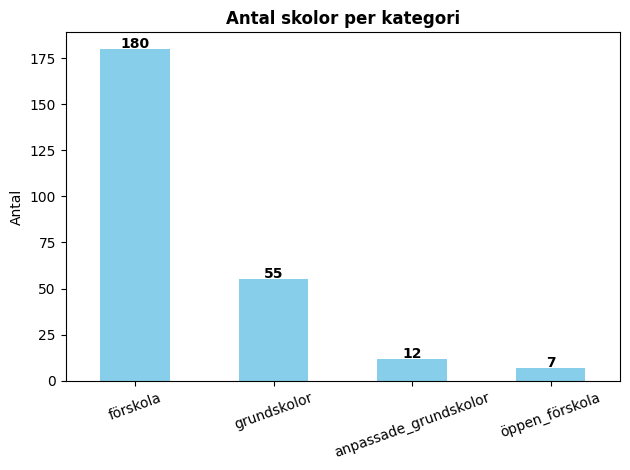

In [38]:
ax = categories.plot(kind='bar', x='kategori', y='antal', legend=False, color='skyblue')
ax.set_title('Antal skolor per kategori', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Antal')
ax.tick_params(axis='x', rotation=20)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Fördelning per stadsdelsområde

In [39]:
stadsdel = duckdb.sql("""
    SELECT stad, COUNT(*) as antal
    FROM df2
    GROUP BY stad
    ORDER BY antal DESC
""").df()

stadsdel

,stad,antal
0,Bromma,120
1,Hägersten,85
2,Älvsjö,49


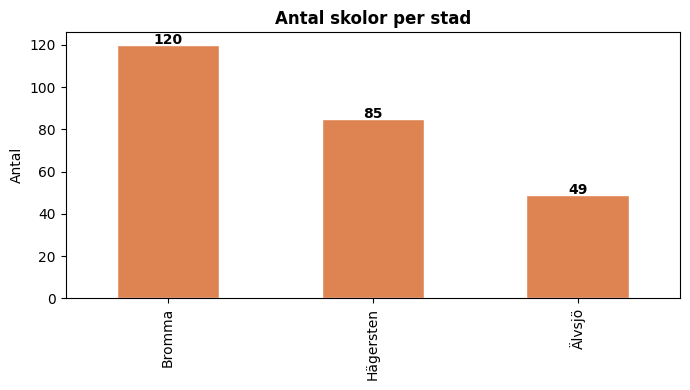

In [40]:
ax = stadsdel.plot(kind='bar', x='stad', y='antal', legend=False,
                   color='#DD8452', edgecolor='white', figsize=(7, 4))
ax.set_title('Antal skolor per stad', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Antal')
ax.tick_params(axis='x')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

procentuell fördelning

In [41]:
procent_förd = duckdb.sql("""
    SELECT kategori, COUNT(*) as antal
    FROM df2
    GROUP BY kategori
    ORDER BY antal DESC
""").df()

procent_förd

,kategori,antal
0,förskola,180
1,grundskolor,55
2,anpassade_grundskolor,12
3,öppen_förskola,7


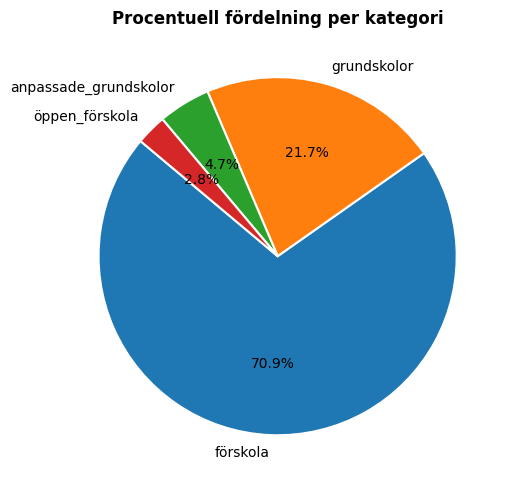

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(procent_förd['antal'], labels=procent_förd['kategori'],
       autopct='%1.1f%%', startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Procentuell fördelning per kategori', fontweight='bold')
plt.tight_layout()
plt.show()